# Brain Tumor Classifier using PyTorch

- classifies MRI scans as glioma, meningioma, pituitary, or no tumor  
- uses a small cnn with a few conv and dense layers  
- trains on 256x256 grayscale images from images/Training and images/Testing  
- tracks training and validation accuracy each epoch  
- includes a quick test function to predict any single image and show its confidence


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
])


In [2]:
train_dataset = datasets.ImageFolder(root="images/Training", transform=transform)
test_dataset = datasets.ImageFolder(root="images/Testing", transform=transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_dataset.classes)
print("Number of training samples:", len(train_dataset))
print("Number of testing samples:", len(test_dataset))


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training samples: 5712
Number of testing samples: 1311


In [3]:
class BrainTumorCNN(nn.Module):
    def __init__(self):
        super(BrainTumorCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 4)  # 4 output classes

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(-1, 64 * 32 * 32)  # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [4]:
# Hyperparameters
EPOCHS = 10
LR = 0.001
BATCH_SIZE = 32
EVAL_EVERY = 1

criterion = nn.CrossEntropyLoss()
model = BrainTumorCNN()
optimizer = optim.Adam(model.parameters(), lr=LR)


In [5]:
def train_brain_tumor_model(model, train_loader, test_loader, criterion, optimizer, epochs=EPOCHS):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        avg_train_loss = total_loss / len(train_loader.dataset)
        train_acc = 100 * correct / len(train_loader.dataset)

        # Evaluate
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        avg_val_loss = val_loss / len(test_loader.dataset)
        val_acc = 100 * val_correct / len(test_loader.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs


In [6]:
# Train Model(may take a while) - adjust hyperparameters first - see above
train_losses, val_losses, train_accs, val_accs = train_brain_tumor_model(
    model, train_loader, test_loader, criterion, optimizer, epochs=EPOCHS
)

torch.save(model.state_dict(), "brain_tumor_cnn.pth")


Epoch 1/10 | Train Loss: 0.6677 | Train Acc: 75.61% | Val Loss: 0.5176 | Val Acc: 80.47%
Epoch 2/10 | Train Loss: 0.3256 | Train Acc: 88.04% | Val Loss: 0.3274 | Val Acc: 87.87%
Epoch 3/10 | Train Loss: 0.1811 | Train Acc: 93.36% | Val Loss: 0.2565 | Val Acc: 91.91%
Epoch 4/10 | Train Loss: 0.1048 | Train Acc: 96.18% | Val Loss: 0.1690 | Val Acc: 94.89%
Epoch 5/10 | Train Loss: 0.0640 | Train Acc: 98.04% | Val Loss: 0.1752 | Val Acc: 95.12%
Epoch 6/10 | Train Loss: 0.0580 | Train Acc: 98.04% | Val Loss: 0.3060 | Val Acc: 91.99%
Epoch 7/10 | Train Loss: 0.0268 | Train Acc: 99.11% | Val Loss: 0.1548 | Val Acc: 95.58%
Epoch 8/10 | Train Loss: 0.0334 | Train Acc: 99.02% | Val Loss: 0.2758 | Val Acc: 93.82%
Epoch 9/10 | Train Loss: 0.0217 | Train Acc: 99.07% | Val Loss: 0.2134 | Val Acc: 96.49%
Epoch 10/10 | Train Loss: 0.0075 | Train Acc: 99.84% | Val Loss: 0.2238 | Val Acc: 96.03%


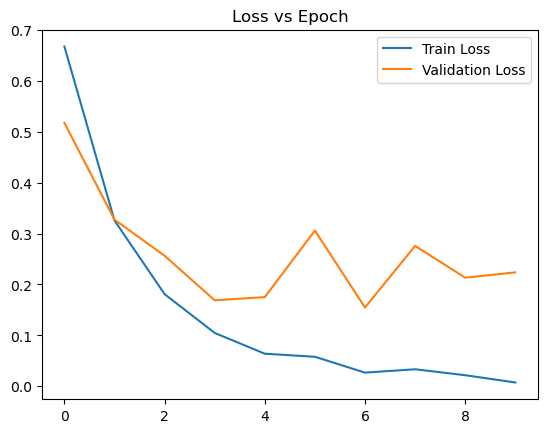

In [7]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epoch')
plt.show()


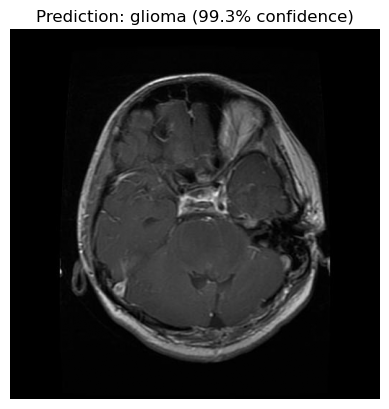

Prediction for '/Users/vinayak/Desktop/CS-4641-Group-130/src/images/Testing/glioma/Te-gl_0010.jpg': glioma
Confidence: 99.29%

Class probabilities:
  glioma      : 99.29%
  meningioma  : 0.31%
  notumor     : 0.00%
  pituitary   : 0.41%


('glioma', 99.28531050682068)

In [22]:
# Single Image Prediction
from PIL import Image
import torch.nn.functional as F

def predict_single_image(model, image_path: str, transform, class_names, show_all_probs=True):

    image = Image.open(image_path).convert("L")
    image_tensor = transform(image).unsqueeze(0)

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)
    image_tensor = image_tensor.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    predicted_class = class_names[predicted.item()]
    confidence_pct = confidence.item() * 100

    plt.imshow(image, cmap="gray")
    plt.title(f"Prediction: {predicted_class} ({confidence_pct:.1f}% confidence)")
    plt.axis("off")
    plt.show()

    print(f"Prediction for '{image_path}': {predicted_class}")
    print(f"Confidence: {confidence_pct:.2f}%")

    if show_all_probs:
        print("\nClass probabilities:")
        for i, cls in enumerate(class_names):
            print(f"  {cls:12s}: {probs[0, i].item() * 100:.2f}%")

    return predicted_class, confidence_pct

# Copy the path of a jpg in the testing data folder and paste it below to test individual images.
# Use images/ directory (not dataset/) as this is what the model was trained on
test_image_path = "/Users/vinayak/Desktop/CS-4641-Group-130/src/images/Testing/glioma/Te-gl_0010.jpg"
predict_single_image(model, test_image_path, transform, train_dataset.classes)



In [23]:
# Model Evaluation and Confidence Analysis
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import torch.nn.functional as F

def evaluate_model_comprehensive(model, train_loader, test_loader, class_names):
    """
    Comprehensive model evaluation with confidence statistics
    """
    model.eval()
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)
    
    def evaluate_dataset(data_loader, dataset_name):
        all_predictions = []
        all_labels = []
        all_confidences = []
        correct_predictions = 0
        total_samples = 0
        
        with torch.no_grad():
            for images, labels in data_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                
                # Get probabilities and predictions
                probs = F.softmax(outputs, dim=1)
                confidences, predictions = torch.max(probs, 1)
                
                # Store results
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_confidences.extend(confidences.cpu().numpy())
                
                # Calculate accuracy
                correct_predictions += (predictions == labels).sum().item()
                total_samples += labels.size(0)
        
        accuracy = 100 * correct_predictions / total_samples
        avg_confidence = np.mean(all_confidences)
        confidence_std = np.std(all_confidences)
        
        return {
            'predictions': all_predictions,
            'labels': all_labels,
            'confidences': all_confidences,
            'accuracy': accuracy,
            'avg_confidence': avg_confidence,
            'confidence_std': confidence_std,
            'total_samples': total_samples,
            'correct_predictions': correct_predictions
        }
    
    # Evaluate both datasets
    print("="*60)
    print("COMPREHENSIVE MODEL EVALUATION REPORT")
    print("="*60)
    
    train_results = evaluate_dataset(train_loader, "Training")
    test_results = evaluate_dataset(test_loader, "Testing")
    
    # Print summary statistics
    print(f"\nOVERALL ACCURACY SUMMARY:")
    print(f"Training Accuracy:   {train_results['accuracy']:.2f}%")
    print(f"Testing Accuracy:    {test_results['accuracy']:.2f}%")
    print(f"Difference:  {train_results['accuracy'] - test_results['accuracy']:.2f}%")
    
    print(f"\nCONFIDENCE STATISTICS:")
    print(f"Training - Average Confidence: {train_results['avg_confidence']:.4f} ± {train_results['confidence_std']:.4f}")
    print(f"Testing  - Average Confidence: {test_results['avg_confidence']:.4f} ± {test_results['confidence_std']:.4f}")
    
    # Confidence by correctness
    train_correct_mask = np.array(train_results['predictions']) == np.array(train_results['labels'])
    test_correct_mask = np.array(test_results['predictions']) == np.array(test_results['labels'])
    
    train_conf_correct = np.array(train_results['confidences'])[train_correct_mask]
    train_conf_wrong = np.array(train_results['confidences'])[~train_correct_mask]
    test_conf_correct = np.array(test_results['confidences'])[test_correct_mask]
    test_conf_wrong = np.array(test_results['confidences'])[~test_correct_mask]
    
    print(f"\nCONFIDENCE BY PREDICTION CORRECTNESS:")
    print(f"Training - Correct predictions: {np.mean(train_conf_correct):.4f} ± {np.std(train_conf_correct):.4f}")
    print(f"Training - Incorrect predictions: {np.mean(train_conf_wrong):.4f} ± {np.std(train_conf_wrong):.4f}")
    print(f"Testing  - Correct predictions: {np.mean(test_conf_correct):.4f} ± {np.std(test_conf_correct):.4f}")
    print(f"Testing  - Incorrect predictions: {np.mean(test_conf_wrong):.4f} ± {np.std(test_conf_wrong):.4f}")
    
    # Per-class accuracy
    print(f"\nPER-CLASS PERFORMANCE (Testing Set):")
    test_report = classification_report(test_results['labels'], test_results['predictions'], 
                                      target_names=class_names, output_dict=True, zero_division=0)
    
    for class_name in class_names:
        precision = test_report[class_name]['precision']
        recall = test_report[class_name]['recall']
        f1 = test_report[class_name]['f1-score']
        support = int(test_report[class_name]['support'])
        print(f"{class_name:12s}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, Samples={support}")
    
    # Macro averages
    macro_avg = test_report['macro avg']
    print(f"\nMacro Average: Precision={macro_avg['precision']:.3f}, Recall={macro_avg['recall']:.3f}, F1={macro_avg['f1-score']:.3f}")
    
    return train_results, test_results

# Run comprehensive evaluation
train_eval, test_eval = evaluate_model_comprehensive(model, train_loader, test_loader, train_dataset.classes)

COMPREHENSIVE MODEL EVALUATION REPORT

OVERALL ACCURACY SUMMARY:
Training Accuracy:   99.89%
Testing Accuracy:    96.03%
Difference:  3.86%

CONFIDENCE STATISTICS:
Training - Average Confidence: 0.9965 ± 0.0244
Testing  - Average Confidence: 0.9838 ± 0.0642

CONFIDENCE BY PREDICTION CORRECTNESS:
Training - Correct predictions: 0.9969 ± 0.0216
Training - Incorrect predictions: 0.6728 ± 0.1320
Testing  - Correct predictions: 0.9889 ± 0.0488
Testing  - Incorrect predictions: 0.8597 ± 0.1736

PER-CLASS PERFORMANCE (Testing Set):
glioma      : Precision=0.922, Recall=0.947, F1=0.934, Samples=300
meningioma  : Precision=0.944, Recall=0.886, F1=0.914, Samples=306
notumor     : Precision=0.985, Recall=1.000, F1=0.993, Samples=405
pituitary   : Precision=0.980, Recall=0.997, F1=0.988, Samples=300

Macro Average: Precision=0.958, Recall=0.957, F1=0.957

OVERALL ACCURACY SUMMARY:
Training Accuracy:   99.89%
Testing Accuracy:    96.03%
Difference:  3.86%

CONFIDENCE STATISTICS:
Training - Average 

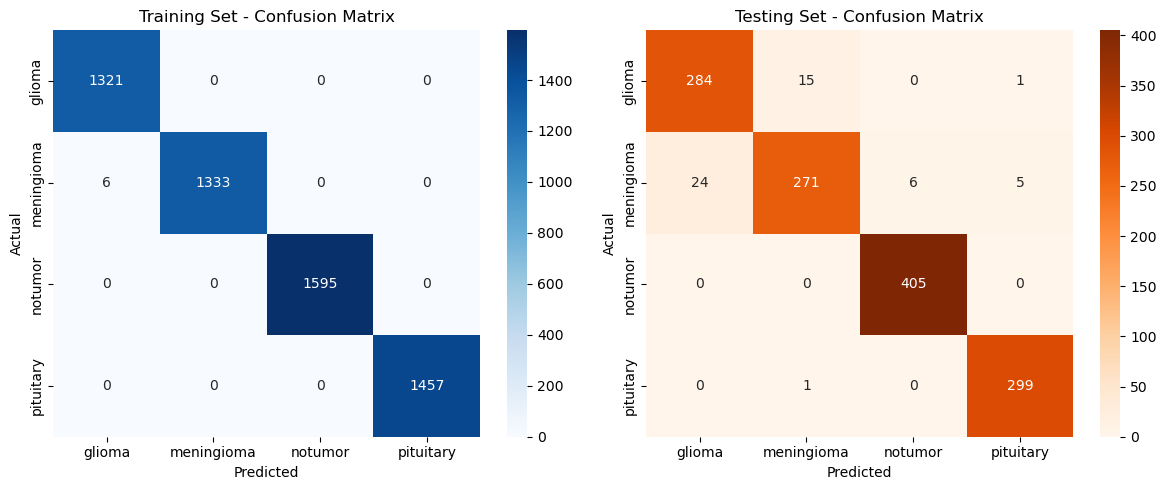


DETAILED CLASSIFICATION REPORT

CLASSIFICATION REPORT (Testing Set):
              precision    recall  f1-score   support

      glioma      0.922     0.947     0.934       300
  meningioma      0.944     0.886     0.914       306
     notumor      0.985     1.000     0.993       405
   pituitary      0.980     0.997     0.988       300

    accuracy                          0.960      1311
   macro avg      0.958     0.957     0.957      1311
weighted avg      0.960     0.960     0.960      1311


CONFIDENCE ANALYSIS SUMMARY:
Average confidence on correct predictions: 0.9889
Average confidence on incorrect predictions: 0.8597

ERROR ANALYSIS:
Total errors: 52 out of 1311 samples (3.97%)


In [24]:
# Confusion Matrices Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training Confusion Matrix
cm_train = confusion_matrix(train_eval['labels'], train_eval['predictions'])
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
           xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, ax=axes[0])
axes[0].set_title('Training Set - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Testing Confusion Matrix
cm_test = confusion_matrix(test_eval['labels'], test_eval['predictions'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
           xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, ax=axes[1])
axes[1].set_title('Testing Set - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Text-based metrics
print("\nDETAILED CLASSIFICATION REPORT")
print("="*50)

# Classification report
print(f"\nCLASSIFICATION REPORT (Testing Set):")
print(classification_report(test_eval['labels'], test_eval['predictions'], 
                          target_names=train_dataset.classes, digits=3))

# Confidence statistics summary
print(f"\nCONFIDENCE ANALYSIS SUMMARY:")
print(f"Average confidence on correct predictions: {np.mean(np.array(test_eval['confidences'])[np.array(test_eval['predictions']) == np.array(test_eval['labels'])]):.4f}")
print(f"Average confidence on incorrect predictions: {np.mean(np.array(test_eval['confidences'])[np.array(test_eval['predictions']) != np.array(test_eval['labels'])]):.4f}")

# Error analysis
errors = np.array(test_eval['predictions']) != np.array(test_eval['labels'])
total_errors = np.sum(errors)
print(f"\nERROR ANALYSIS:")
print(f"Total errors: {total_errors} out of {len(test_eval['labels'])} samples ({100*total_errors/len(test_eval['labels']):.2f}%)")

In [25]:
# Summary for Report
def generate_report_summary(train_eval, test_eval, class_names):
    """
    Generate a formatted summary suitable for academic reports
    """
    print("="*70)
    print("BRAIN TUMOR CLASSIFICATION MODEL - PERFORMANCE REPORT")
    print("="*70)
    
    print(f"\nMODEL ARCHITECTURE:")
    print(f"   • 3-layer Convolutional Neural Network")
    print(f"   • Input: 256×256 grayscale MRI images")
    print(f"   • Classes: {', '.join(class_names)}")
    print(f"   • Training samples: {train_eval['total_samples']:,}")
    print(f"   • Testing samples: {test_eval['total_samples']:,}")
    
    print(f"\nMODEL PERFORMANCE METRICS:")
    print(f"   Training Accuracy:    {train_eval['accuracy']:.2f}%")
    print(f"   Testing Accuracy:     {test_eval['accuracy']:.2f}%")
    print(f"   Generalization Gap:   {train_eval['accuracy'] - test_eval['accuracy']:.2f}%")
    
    # Calculate additional metrics
    train_error_rate = 100 - train_eval['accuracy']
    test_error_rate = 100 - test_eval['accuracy']
    
    print(f"   Training Error Rate:  {train_error_rate:.2f}%")
    print(f"   Testing Error Rate:   {test_error_rate:.2f}%")
    
    print(f"\nMODEL CONFIDENCE ANALYSIS:")
    print(f"   Training Average Confidence:  {train_eval['avg_confidence']:.4f} (σ={train_eval['confidence_std']:.4f})")
    print(f"   Testing Average Confidence:   {test_eval['avg_confidence']:.4f} (σ={test_eval['confidence_std']:.4f})")
    
    # Confidence ranges
    train_conf_min, train_conf_max = min(train_eval['confidences']), max(train_eval['confidences'])
    test_conf_min, test_conf_max = min(test_eval['confidences']), max(test_eval['confidences'])
    
    print(f"   Training Confidence Range: [{train_conf_min:.4f}, {train_conf_max:.4f}]")
    print(f"   Testing Confidence Range:  [{test_conf_min:.4f}, {test_conf_max:.4f}]")
    
    # Per-class metrics for testing set
    print(f"\nPER-CLASS TESTING PERFORMANCE:")
    test_report = classification_report(test_eval['labels'], test_eval['predictions'], 
                                      target_names=class_names, output_dict=True, zero_division=0)
    
    print(f"   {'Class':<12} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<8}")
    print(f"   {'-'*52}")
    
    for class_name in class_names:
        metrics = test_report[class_name]
        print(f"   {class_name:<12} {metrics['precision']:<10.3f} {metrics['recall']:<10.3f} "
              f"{metrics['f1-score']:<10.3f} {int(metrics['support']):<8}")
    
    # Overall metrics
    macro_avg = test_report['macro avg']
    weighted_avg = test_report['weighted avg']
    
    print(f"   {'-'*52}")
    print(f"   {'Macro Avg':<12} {macro_avg['precision']:<10.3f} {macro_avg['recall']:<10.3f} "
          f"{macro_avg['f1-score']:<10.3f}")
    print(f"   {'Weighted Avg':<12} {weighted_avg['precision']:<10.3f} {weighted_avg['recall']:<10.3f} "
          f"{weighted_avg['f1-score']:<10.3f}")
    
    print(f"\nKEY FINDINGS:")
    
    # Overfitting analysis
    generalization_gap = train_eval['accuracy'] - test_eval['accuracy']
    if generalization_gap > 5:
        print(f"   • Model shows signs of overfitting (gap: {generalization_gap:.1f}%)")
    elif generalization_gap < 1:
        print(f"   • Excellent generalization (gap: {generalization_gap:.1f}%)")
    else:
        print(f"   • Good generalization (gap: {generalization_gap:.1f}%)")
    
    # Confidence analysis
    conf_diff = train_eval['avg_confidence'] - test_eval['avg_confidence']
    if abs(conf_diff) < 0.02:
        print(f"   • Consistent confidence across datasets")
    else:
        print(f"   • Confidence differs between train/test ({conf_diff:.4f})")
    
    # Best performing class
    best_class = max(class_names, key=lambda x: test_report[x]['f1-score'])
    worst_class = min(class_names, key=lambda x: test_report[x]['f1-score'])
    
    print(f"   • Best performing class: {best_class} (F1: {test_report[best_class]['f1-score']:.3f})")
    print(f"   • Most challenging class: {worst_class} (F1: {test_report[worst_class]['f1-score']:.3f})")
    
    print(f"\n" + "="*70)

# Generate comprehensive report
generate_report_summary(train_eval, test_eval, train_dataset.classes)

BRAIN TUMOR CLASSIFICATION MODEL - PERFORMANCE REPORT

MODEL ARCHITECTURE:
   • 3-layer Convolutional Neural Network
   • Input: 256×256 grayscale MRI images
   • Classes: glioma, meningioma, notumor, pituitary
   • Training samples: 5,712
   • Testing samples: 1,311

MODEL PERFORMANCE METRICS:
   Training Accuracy:    99.89%
   Testing Accuracy:     96.03%
   Generalization Gap:   3.86%
   Training Error Rate:  0.11%
   Testing Error Rate:   3.97%

MODEL CONFIDENCE ANALYSIS:
   Training Average Confidence:  0.9965 (σ=0.0244)
   Testing Average Confidence:   0.9838 (σ=0.0642)
   Training Confidence Range: [0.5023, 1.0000]
   Testing Confidence Range:  [0.4903, 1.0000]

PER-CLASS TESTING PERFORMANCE:
   Class        Precision  Recall     F1-Score   Support 
   ----------------------------------------------------
   glioma       0.922      0.947      0.934      300     
   meningioma   0.944      0.886      0.914      306     
   notumor      0.985      1.000      0.993      405     
   